## Correlation Analysis
### Spectral to Photosynthesis Traits
Uses QY_max for Fv/Fm and NPQ_L7 for NPQ. Note that we have to remove plots that we do not have both spectral and physiological data for (correlations cannot work when we have nans).

In [1]:
# import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [2]:
# Load Data
spectra_df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/corrected_data_group_means.csv', index_col=1)
pca_scores_df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/PCA_table_h20removed_6only.csv', index_col=0)
lda_scores_df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/lda_raw_spectra_scores_group_means.csv', index_col=0)
indices_df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/drought_spectral_indices_group_means.csv', index_col=0)
traits_df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/physiological_traits.csv', index_col=0)


In [3]:
# Make a copy
traits_df = traits_df.copy()

# Convert traits to numeric
traits_df = traits_df.apply(pd.to_numeric, errors='coerce')
spectra_df = spectra_df.apply(pd.to_numeric, errors='coerce')
pca_scores_df = pca_scores_df.apply(pd.to_numeric, errors='coerce')
lda_scores_df = lda_scores_df.apply(pd.to_numeric, errors='coerce')
indices_df = indices_df.apply(pd.to_numeric, errors='coerce')

In [4]:
# Filter to only use plots with both spectral and agronomic data
    # Keep only plots with both QY_max (Fv/Fm) and NPQ_L7
traits_filtered = traits_df.dropna(subset=['QY_max', 'NPQ_L7']).copy()

# Align other data to available plots
spectra_filtered = spectra_df.loc[traits_filtered.index]
pca_filtered = pca_scores_df.loc[traits_filtered.index]
lda_filtered = lda_scores_df.loc[traits_filtered.index]
indices_filtered = indices_df.loc[traits_filtered.index]

print(f"Number of plots used for correlations: {len(traits_filtered)}")

Number of plots used for correlations: 23


In [5]:
# General Correlation function

def correlation_matrix(x_df, y_df, method='pearson'):
    """
    Computes pairwise correlation between all columns in x_df and y_df.
    Handles NaNs safely.
    """
    corr_mat = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    pval_mat = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    
    for x_col in x_df.columns:
        for y_col in y_df.columns:
            x = x_df[x_col]
            y = y_df[y_col]
            
            mask = x.notna() & y.notna()
            if mask.sum() < 2:
                corr_mat.loc[x_col, y_col] = np.nan
                pval_mat.loc[x_col, y_col] = np.nan
            else:
                if method == 'pearson':
                    r, p = pearsonr(x[mask], y[mask])
                elif method == 'spearman':
                    r, p = spearmanr(x[mask], y[mask])
                corr_mat.loc[x_col, y_col] = r
                pval_mat.loc[x_col, y_col] = p
                
    return corr_mat.astype(float), pval_mat.astype(float)

In [6]:
# Correlate spectra, PCA, and LDA with physiological traits using pearsons or spearmans correlation

# Choose traits to correlate with
traits_to_use = traits_filtered[['QY_max', 'NPQ_L7', 'YieldT']]

# Spectra
corr_spectra_pearson, p_spectra_pearson = correlation_matrix(spectra_filtered, traits_to_use, method='pearson')
corr_spectra_spearman, p_spectra_spearman = correlation_matrix(spectra_filtered, traits_to_use, method='spearman')

# PCA scores
corr_pca_pearson, p_pca_pearson = correlation_matrix(pca_filtered, traits_to_use, method='pearson')
corr_pca_spearman, p_pca_spearman = correlation_matrix(pca_filtered, traits_to_use, method='spearman')

# LDA scores
corr_lda_pearson, p_lda_pearson = correlation_matrix(lda_filtered, traits_to_use, method='pearson')
corr_lda_spearman, p_lda_spearman = correlation_matrix(lda_filtered, traits_to_use, method='spearman')

In [7]:
# Correlate spectral indices with physiological traits

corr_indices_pearson, p_indices_pearson = correlation_matrix(indices_filtered, traits_to_use, method='pearson')
corr_indices_spearman, p_indices_spearman = correlation_matrix(indices_filtered, traits_to_use, method='spearman')

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

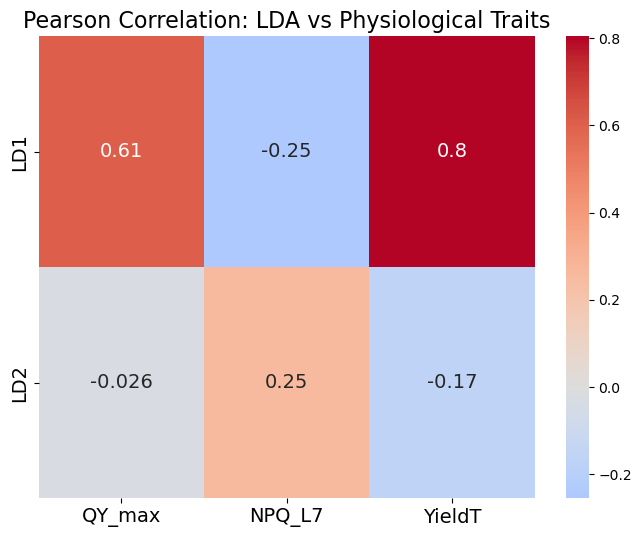

In [10]:
# plot as heat map,  seitching out "corr_lda_pearson" for which every variables you want to correlate
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_lda_pearson,
    annot=True,
    cmap='coolwarm',
    center=0,
    annot_kws={"size": 14}
)

plt.title("Pearson Correlation: LDA vs Physiological Traits", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.savefig("C:/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/correlation_lda.png", dpi=300, bbox_inches="tight")  # save image
plt.tight_layout